<a href="https://colab.research.google.com/github/achoppement/WaveWeave/blob/main/WaveWeave_20260930.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction

In [ ]:
## 入力
stock_a_name = "SONY"
stock_a_code = "6758.T"
stock_b_name = "HITACHI"
stock_b_code = "6501.T"

## 2-1. 前準備

In [ ]:
!pip install fastdtw
!pip install japanize_matplotlib
import datetime
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
import matplotlib as mpl
import japanize_matplotlib
import warnings
from google.colab import files
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp313-cp313-linux_x86_64.whl size=551003 sha256=a2b7eda7471a442d6e0f7f6e42e6a49ccc30852b961207ff02eb69ec81f1124a
  Stored in directory: /root/.cache/pip/wheels/2c/9e/6d/6c419b5fe1b720cf2f9c7b20ea119dc201878ea890ba26221f
Successfully built fastdtw
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 30.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=b6ad23f63367c124e5c628c17cd29e2cde24b1c730aba69a5db5c096cbad9105
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize_matplotlib


In [ ]:
"""import datetime
dt_now_jst_aware = datetime.datetime.now(
    datetime.timezone(datetime.timedelta(hours=9))
)
dt_now_jst_aware = dt_now_jst_aware - datetime.timedelta(days=dt_now_jst_aware.day-11)

last_month = dt_now_jst_aware - datetime.timedelta(days=dt_now_jst_aware.day)
last_month_last_day = str(last_month)[:10]
yesterday = dt_now_jst_aware - datetime.timedelta(days=1)
yesterday = str(yesterday)[:10]
last_month_last_day, yesterday"""

##################　   変更箇所     #####################
yesterday = "2026-09-10"
last_month_last_day ="2026-08-31"
last_month = last_month_last_day[:7]

In [ ]:
# ============================
# 1. データの取得
# ============================
print("[ステップ 1] データ取得中...")

# 指数のティッカーシンボル定義

tickers = {
    stock_a_name:stock_a_code,
    stock_b_name: stock_b_code
}
# データ期間の設定
start_date = '2000-01-01'
end_date = yesterday

# データのダウンロード
data = {}
for name, ticker in tickers.items():
    print(f"  - {name} ({ticker}) をダウンロード中...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    data[name] = df.loc[:, 'Close'] # Select only the 'Close' column
    print(f"    取得データ数: {len(df)} 日分,期間: {df.index[0].date()} ~ {df.index[-1].date()} ")

# データフレームに統合
df_prices = pd.concat(data,axis=1)

[ステップ 1] データ取得中...
  - SONY (6758.T) をダウンロード中...
    取得データ数: 6659 日分,期間: 2000-01-04 ~ 2026-09-09 
  - HITACHI (6501.T) をダウンロード中...
    取得データ数: 6659 日分,期間: 2000-01-04 ~ 2026-09-09 


In [ ]:
# ============================
# 2. 月次データの準備
# ============================
print("[ステップ 2] 月次データの準備...")

def prepare_monthly_data(df_prices):
    """
    日次価格データを月次に分割し、各月のデータを辞書として返す

    Returns:
        monthly_data: {index_name: {year-month: array of daily prices}}
        monthly_returns: {index_name: {year-month: monthly return}}
    """
    monthly_data = {name: {} for name in tickers.keys()}
    monthly_returns = {name: {} for name in tickers.keys()}

    last_and_this_month = {name: {} for name in tickers.keys()}
    # 月ごとにグループ化
    df_prices['year_month'] = df_prices.index.to_period('M')

    for name in tickers.keys():  # 'year_month'列を除く
        for ym in df_prices['year_month'].unique():
            tmp = df_prices.loc[df_prices['year_month'] == ym][name].dropna().values
            month_data = []
            for i in range(len(tmp)):
                month_data.append(tmp[i][0])
            if str(ym) == last_month_last_day[:7]:
                last_and_this_month[name][str(ym)] = month_data
            if str(ym) == yesterday[:7]:
                last_and_this_month[name][str(ym)] = month_data
                continue

            # 月内に少なくとも5営業日あることを確認
            if len(month_data) >= 1:
                monthly_data[name][str(ym)] = month_data

                # 月次リターンの計算: (月末価格 / 月初価格) - 1
                monthly_return = (month_data[-1] / month_data[0]) - 1
                monthly_returns[name][str(ym)] = monthly_return
    print(ym)
    return monthly_data, monthly_returns, last_and_this_month

monthly_data, monthly_returns, last_and_this_month = prepare_monthly_data(df_prices)

# 全ての指数で共通する月を取得
common_months = set(monthly_data[list(tickers.keys())[0]].keys())
for name in tickers.keys():
    common_months = common_months.intersection(set(monthly_data[name].keys()))

common_months = sorted(list(common_months))
print(f"共通月数: {len(common_months)}")
print(f"最初の月: {common_months[0]}, 最後の月: {common_months[-1]}")
print()


[ステップ 2] 月次データの準備...
2026-09
共通月数: 320
最初の月: 2000-01, 最後の月: 2026-08



In [ ]:
# ============================
# 3. IDTW距離の計算
# ============================
print("[ステップ 3] IDTW実装...")

def calculate_idtw(x, y):
    """
    IDTW (Indexing Dynamic Time Warping) 距離を計算

    Algorithm 3 に基づく実装:
    1. 各時系列を指数化（相対変化率の累積）
    2. 指数化された時系列間のDTW距離を計算

    Args:
        x, y: 価格の時系列データ（numpy array）

    Returns:
        IDTW距離（float）
    """
    # Step 1: 指数化（Indexing）
    # Ix[1] = 1, Ix[i] = Ix[i-1] * (x[i] / x[i-1])
    Ix = np.zeros(len(x))
    Iy = np.zeros(len(y))

    Ix[0] = 1.0
    Iy[0] = 1.0

    for i in range(1, len(x)):
        Ix[i] = Ix[i-1] * (x[i] / x[i-1])

    for j in range(1, len(y)):
        Iy[j] = Iy[j-1] * (y[j] / y[j-1])

    # Step 2: DTW距離の計算
    # fastdtwを使用してDTW距離を計算
    distance, _ = fastdtw(Ix.reshape(-1, 1), Iy.reshape(-1, 1), dist=euclidean)

    return distance
print("IDTW実装完了")

[ステップ 3] IDTW実装...
IDTW実装完了


In [ ]:
# ========================
# 4. k*-NNで予測
# ========================
print("[ステップ 4] k*-NN実装...")
def calculate_ksnn(labels, distances, L_C=1.0):
    """
    k*-NN (k*-Nearest Neighbors) による予測

    Algorithm 5 および添付のC++コードに基づく実装:
    1. 距離を昇順にソートし、L/Cを掛けてβを作成
    2. Lambdaを計算（最適なkを自動決定）
    3. 重みαを計算
    4. 加重平均で予測値を返す

    Args:
        labels: ラベル（翌月リターン）の-array- df
        distances: 対象月と各月との距離の-array- df
        L_C: ハイパーパラメータ L/C

    Returns:
        pred: 予測値
        alpha: 重みベクトル
        k_star: 選択されたk
    """
    n = len(distances.index)

    # 距離でソート
    dist_lab_df = pd.concat([distances,labels],axis=1)
    dist_lab_df_sorted = dist_lab_df.sort_values("distance")
    sorted_distances= dist_lab_df_sorted["distance"]
    sorted_labels = dist_lab_df_sorted["label"]
    top3_labels = sorted_labels[:3]

    # βの計算: β[i] = L/C × distance[i]
    beta = L_C * sorted_distances

    # Lambdaの計算（Algorithm 5の5-8行目）
    lam = np.zeros(n)

    beta_sum = 0.0
    beta2_sum = 0.0
    k = 0
    while k == 0 or (k< n-1 and lam[k] > beta[k+1]):
        k = k+1
        beta_sum += beta[k]
        beta2_sum += beta[k] ** 2

        # Lambda[k+1]の計算式（Algorithm 5の7行目）
        tmp = (1.0 / k) * (
            beta_sum + np.sqrt(k + beta_sum**2 - k * beta2_sum)
        )
        lam[k] = tmp

    # k_star = k_plus_1  # 選択されたk
    #  tail_lambda = lam[k_star] if k_star < len(lam) else lam[-1]
    tail_lambda = lam[k]
    # print(k, lam[k])

    # 重みαの計算（Algorithm 5の9-12行目）
    alpha = []
    lam_beta_sum = 0
    for i in range(n):
        if beta[i] < tail_lambda:
            lam_beta_sum += tail_lambda - beta[i]
    for i in range(n):
        if beta[i] < tail_lambda:
            alpha.append((tail_lambda - beta[i])/lam_beta_sum)

    alpha_df = pd.DataFrame(alpha,index=sorted_distances.index[:len(alpha)],columns=['alpha'])

    # 正規化
    if abs(sum(alpha)-1) < 0.01:
        pass
    elif sum(alpha) > 0:
        alpha_df = alpha_df / np.sum(alpha_df)
    else:
        # フォールバック: k=5を使用
        print(f"Fall back! sum(alpha) = {np.sum(alpha)}")
        alpha = np.array([96, 84, 71, 53, 37])
        alpha = alpha / alpha.sum()
        k = 5


    # 波形全体の予測
    pattern_month_list = list(sorted_labels.index[:len(alpha)])
    pattern_data_list = [monthly_data[index_name][v] for v in pattern_month_list]
    data_list = pattern_data_list

    for i in range(len(data_list)):
        data_list[i] = data_list[i]/data_list[i][0]

    target_length = 20
    resampled = []
    for y in data_list:
        x_old = np.linspace(0, 1, len(y))
        x_new = np.linspace(0, 1, target_length)

        y_new = np.interp(x_new, x_old, y)
        resampled.append(y_new)

    pred_pattern = [0 for j in range(target_length)]
    for i in range(len(resampled)):
        resampled[i] = resampled[i] * alpha[i]
        for j in range(target_length):
            pred_pattern[j] = pred_pattern[j] + resampled[i][j]



    # 予測値の計算（加重平均）
    sorted_labels_lim = sorted_labels.iloc[:len(alpha)] # Corrected indexing
    pred = float(np.sum(alpha_df['alpha'] * sorted_labels_lim)) # Corrected multiplication

    return pred, alpha, k, top3_labels, pred_pattern
print('k*-NN実装完了')

[ステップ 4] k*-NN実装...
k*-NN実装完了


In [ ]:
def evaluate(pred, ret, pred_raw, ret_raw):
    # Only evaluate if there are predictions
    if len(pred) > 0:
        # 評価指標の計算
        mae = np.mean(np.abs(pred_raw - ret_raw))
        rmse = np.sqrt(np.mean((pred_raw - ret_raw) ** 2))

        # 正答率（符号の一致）
        # correct_signs = np.sum((pred > THRESHOLD) == (ret > 0))
        # correct_signs = np.sum((pred - THRESHOLD)*(ret) > 0)
        """correct_signs = 0
        for i in range(len(pred)):
            correct_signs += (pred[i] > THRESHOLD) == (ret[i] > 0)
        accuracy = correct_signs / len(pred) * 100"""

        # 売買シミュレーション
        capital = [1.0]  # 初期資本 100%
        n_buys = 0
        n_trades = 0

        correct_signs = 0
        for predicted, actual in zip(pred[1:], ret[1:]):
            # 予測に基づくポジション
            if predicted >THRESHOLD:
                # 買い（ロング）
                capital.append(capital[-1] * (1 + actual))
                n_buys += 1
                n_trades += 1
                if actual > 0:
                    correct_signs += 1
            else:
                # 売り（ショート）
                capital.append(capital[-1] * (1 - actual))
                n_trades += 1
                if actual < 0:
                    correct_signs += 1
            # print(predicted, actual, predicted*actual >0, capital[-1])
        accuracy = correct_signs / len(pred[1:]) * 100
        total_return = (capital[-1] - 1.0) * 100  # 元本からの増加率(%)

        # 結果の保存
        result = {
            'MAE': mae,
            'RMSE': rmse,
            'Accuracy': accuracy,
            'Total_Return': total_return,
            'N_buys': n_buys,
            'N_trades': n_trades,
            'Final_Capital': capital[-1]
        }

        print(f"\n--- {index_name} の結果 ---")
        print(f"正答率: {accuracy:.2f}%")
        print(f"最終資本: {capital[-1]:.4f}X")
        print(f"MAE: {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")

        print(f"購入回数/取引回数: {n_buys} / {n_trades}")
        print(f"総収益率: {total_return:.2f}%")
        print(f"指数変化:{((ret_raw[-1]/ret_raw[0])// 0.001)*0.001}X")
    else:
        print(f"\n--- {index_name} の結果 ---")
        print("No predictions were made due to insufficient data.")
    return result, capital

## 2-2. メイン実行・結果

[ステップ 5] メイン分析の実行...

THRESHOLD = -0.01

指数: SONY
参照期間（初回）: 2000-01 ~ 2026-08 (320ヶ月)
{'2000-01': np.float64(0.1979355544193726), '2000-02': np.float64(-0.10874156584766925), '2000-03': np.float64(-0.17266666463090474), '2000-04': np.float64(-0.22496055902357392), '2000-05': np.float64(0.015384524457290771), '2000-06': np.float64(-0.026112035187296878), '2000-07': np.float64(0.18525883471160065), '2000-08': np.float64(-0.08493900315502201), '2000-09': np.float64(-0.19259255209851267), '2000-10': np.float64(-0.09621633412444763), '2000-11': np.float64(-0.04126189853509643), '2000-12': np.float64(0.0696200799268274), '2001-01': np.float64(0.0011844795923416918), '2001-02': np.float64(0.08418398404042327), '2001-03': np.float64(0.039369933822325454), '2001-04': np.float64(-0.036764648957949175), '2001-05': np.float64(-0.11828003089742078), '2001-06': np.float64(-0.24539867231160462), '2001-07': np.float64(-0.14677432584236272), '2001-08': np.float64(-0.1298338439372092), '2001-09': np.flo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

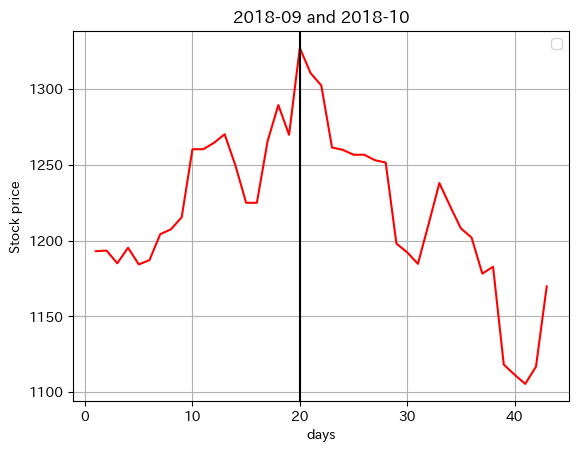

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

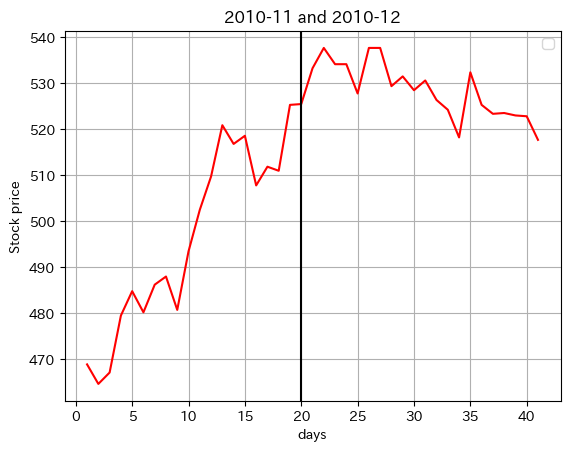

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

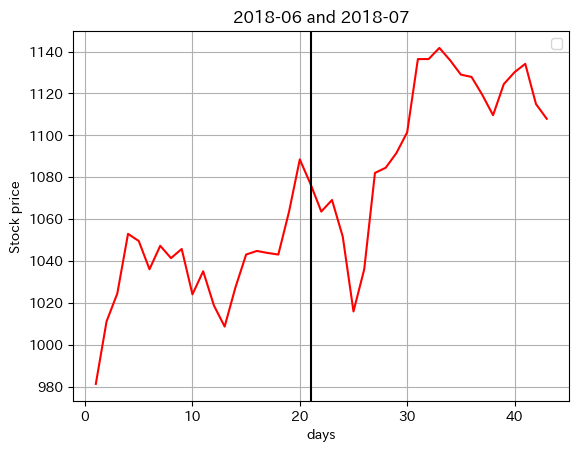


指数: HITACHI
参照期間（初回）: 2000-01 ~ 2026-08 (320ヶ月)
{'2000-01': np.float64(-0.03352663041872428), '2000-02': np.float64(-0.18917740870137845), '2000-03': np.float64(0.004672802778785234), '2000-04': np.float64(-0.03959689361140206), '2000-05': np.float64(0.15037585831183464), '2000-06': np.float64(-0.14657975797657774), '2000-07': np.float64(-0.030698145553592737), '2000-08': np.float64(0.01579590130582975), '2000-09': np.float64(-0.048006285382649616), '2000-10': np.float64(-0.1154814214765284), '2000-11': np.float64(-0.06347727891685473), '2000-12': np.float64(0.0756383846127846), '2001-01': np.float64(-0.058769654804551985), '2001-02': np.float64(0.09687193005488504), '2001-03': np.float64(0.14641131174332722), '2001-04': np.float64(-0.08520154432312), '2001-05': np.float64(-0.01129944117536763), '2001-06': np.float64(-0.11606397049836537), '2001-07': np.float64(-0.09731266580320586), '2001-08': np.float64(-0.10181256850307085), '2001-09': np.float64(0.047678855241979345), '2001-10': n

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

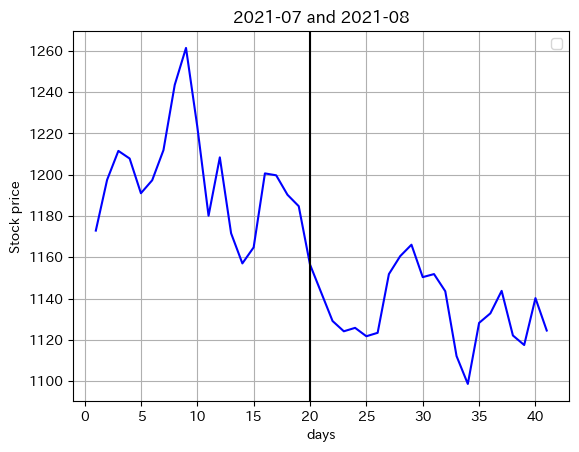

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

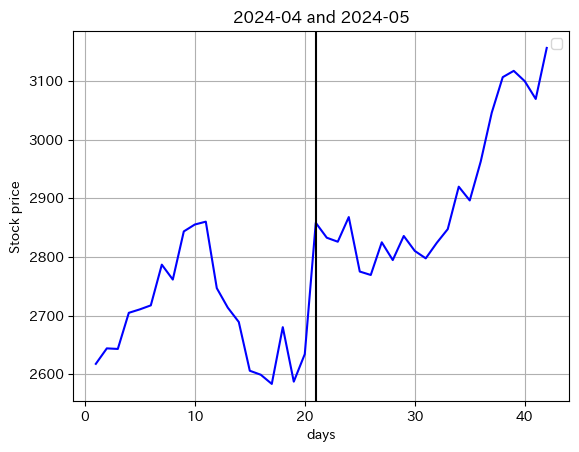

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

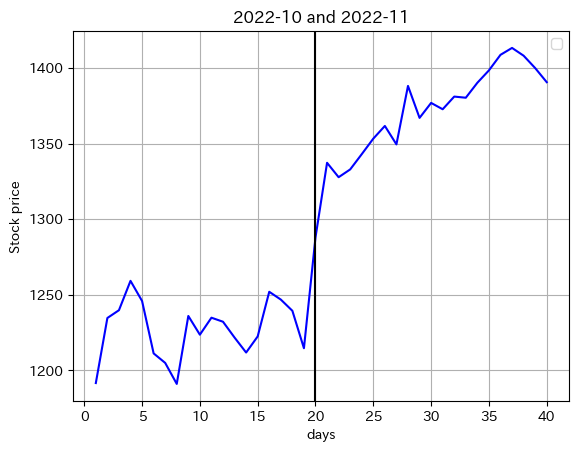

In [ ]:
# ============================
# 5. メイン分析
# ============================
print("[ステップ 5] メイン分析の実行...")
print()

THRESHOLD = -0.01
Iy_ans = {name:[1.0] for name in tickers.keys()}
print(f"THRESHOLD = {THRESHOLD}")

# パラメータ設定
LC_range = [4]

# テスト期間の定義
reference_end_date = str(last_month)[:7]
test_start_date = yesterday[:7]

# 結果を保存する辞書
y_ans = {}
y_ans_raw = {}
y_pred = {}
y_pred_raw = {}
results = {}
colors = ["red","blue"]
pred_pattern_list = []
i = -1
for index_name in tickers.keys():
    i+= 1
    print(f"\n{'='*50}")
    print(f"指数: {index_name}")
    print(f"{'='*50}")

    # 月のリストとリターンを取得
    months = sorted([m for m in monthly_data[index_name].keys()])
    returns_dict = monthly_returns[index_name]

    # 参照期間とテスト期間の分割
    reference_months = [m for m in months if m <= reference_end_date]
    test_months = [test_start_date]

    print(f"参照期間（初回）: {reference_months[0]} ~ {reference_months[-1]} ({len(reference_months)}ヶ月)")
    # print(f"テスト期間: {test_months[0]} ~ {test_months[-1]} ({len(test_months)}ヶ月)") #176 months

    # 予測結果を保存
    predictions = {}

    # -テスト期間の各月で予測-  -> 今月の予測
    # 前月のインデックス
    prev_month_idx = reference_end_date
    prev_month = last_month_last_day[:7]

    # 参照期間（前月より前の全ての月）
    available_months = months[:-1]


    # ============================
    # Step 1: 類似度行列の計算
    # ============================
    # 前月のデータ
    prev_month_data = monthly_data[index_name].get(prev_month)

    # 前月と過去の各月とのIDTW距離を計算
    distances = {}
    valid_past_months = []
    for past_month in available_months:
        past_data = monthly_data[index_name].get(past_month)
        # Add check for empty data
        if prev_month_data is not None and past_data is not None and len(prev_month_data) > 0 and len(past_data) > 0:
            distance = calculate_idtw(prev_month_data, past_data)
            distances[past_month] = distance
            valid_past_months.append(past_month)
        else:
            print(f"Invalid month: {past_month}")

    distances = pd.DataFrame(distances.values(), index=distances.keys(),columns=["distance"])

    # Update available_months to only include valid past months
    available_months = valid_past_months

    # ============================
    # Step 2: k*-NNで翌月リターンを予測
    # ============================
    # ラベル（各月の翌月リターン）を準備
    labels = {} # !!!!! 入っているのは「翌月の」リターン !!!!!
    test_month = yesterday[:7]
    for past_month in available_months:
        past_month_idx = months.index(past_month)
        if past_month_idx+ 1 < len(months):
            next_month = months[past_month_idx + 1]
            if next_month in monthly_returns[index_name]:
                labels[past_month] = (returns_dict[next_month])
            else:
                print(f"No data for next month: {next_month}")
                labels[past_month] =  0 # データがない場合は0
        else:
            # print(f"YES data for next month: {next_month}")
            labels[past_month] = returns_dict[next_month]
    print(labels)
    labels = pd.DataFrame(labels, index=labels.keys(), columns=['label'])
    print(labels)
    # 予測
    tmp_list =[]
    for L_C in LC_range:
        if len(distances.index) and len(labels.index):
            pred, alpha, k_star, top3_labels, pred_pattern = calculate_ksnn(labels, distances, L_C)
            tmp_list.append(pred)
        else:
            print(f"Blank Data for {test_month}")

    predictions[test_month] = tmp_list
    pred_pattern_list.append(pred_pattern)
    print("======予測完了=======")
    print(predictions)

    ## プロット
    # 小グラフ
    for num, m in enumerate(top3_labels.index):
        # データ生成
        y = monthly_data[index_name][m] + monthly_data[index_name][months[months.index(m)+1]]
        x = np.linspace(1, len(y),len(y))

        # プロット作成
        plt.plot(x, y, label="", color=colors[i], linestyle="-")
        plt.title(f"{m} and {months[months.index(m)+1]}") # タイトル設定
        plt.xlabel("days") # X軸ラベル
        plt.ylabel("Stock price") # Y軸ラベル
        plt.legend() # 凡例表示
        plt.grid(True) # グリッド線表示
        plt.axvline(len(monthly_data[index_name][m]),color="black")
        #　plt.show() # グラフ表示
        file_name = f"{yesterday[:7]}_sub_{index_name}_{num+1}_{m}.png"
        plt.savefig(file_name)
        files.download(file_name)
        plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

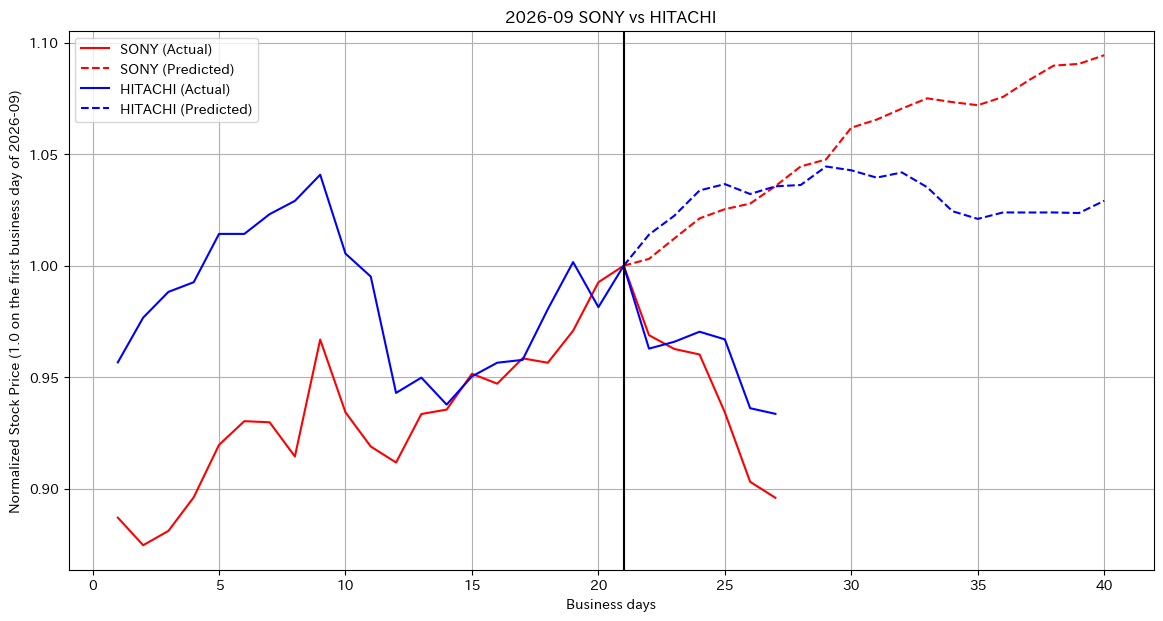

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming pred_pattern_list is already populated from the previous cell
# Assuming last_and_this_month, reference_end_date, test_start_date, tickers are available

plt.figure(figsize=(14, 7))
plot_colors = ['red', 'blue'] # Colors for SONY and HITACHI
line_styles = ['-', '--'] # Line styles for Actual and Predicted

for i, (name, ticker_code) in enumerate(tickers.items()):
    # Get actual data for the last two months
    # Ensure the keys exist before accessing
    last_month_data = last_and_this_month[name].get(last_month, [])
    current_month_data = last_and_this_month[name].get(test_start_date, [])
    actual_combined_data = np.array(last_month_data + current_month_data)

    # Normalize actual data using current_month_data[0] as the base
    actual_normalized = np.array([])
    if len(actual_combined_data) > 0 and len(current_month_data) > 0:
        if current_month_data[0] != 0:
            actual_normalized = actual_combined_data / current_month_data[0]
        else:
            # Handle case where the first element of current_month_data is zero
            actual_normalized = actual_combined_data / (current_month_data[0] + 1e-9) # Add small epsilon

    # Get predicted pattern for the current ticker
    predicted_pattern = pred_pattern_list[i] if i < len(pred_pattern_list) else np.array([])

    # Plot actual data
    if len(actual_normalized) > 0:
        x_actual = np.linspace(1, len(actual_normalized), len(actual_normalized))
        plt.plot(x_actual, actual_normalized, label=f'{name} (Actual)', color=plot_colors[i], linestyle=line_styles[0])

    # Plot predicted pattern (full length)
    if len(predicted_pattern) > 0:
        x_predicted = np.linspace(1, len(predicted_pattern), len(predicted_pattern))
        plt.plot(x_predicted + len(last_and_this_month[name][str(last_month)[:7]]), predicted_pattern, label=f'{name} (Predicted)', color=plot_colors[i], linestyle=line_styles[1])

i, j = tickers.keys()
plt.title(f'{yesterday[:7]} {i} vs {j}')
plt.xlabel('Business days')
plt.ylabel(f'Normalized Stock Price (1.0 on the first business day of {yesterday[:7]})')
plt.legend()
plt.grid(True)
plt.axvline(len(monthly_data[name][str(last_month)[:7]])+1,color="black")
file_name = f"{yesterday[:7]}_main.png"
plt.savefig(file_name)
files.download(file_name)
plt.show()

# Results

In [ ]:
## 入力
stock_a_name = "SONY"
stock_a_code = "6758.T"
stock_b_name = "HITACHI"
stock_b_code = "6501.T"

## 2-1. 前準備

In [ ]:
!pip install fastdtw
!pip install japanize_matplotlib
import datetime
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
import matplotlib as mpl
import japanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
"""import datetime
dt_now_jst_aware = datetime.datetime.now(
    datetime.timezone(datetime.timedelta(hours=9))
)
dt_now_jst_aware = dt_now_jst_aware - datetime.timedelta(days=dt_now_jst_aware.day-11)

last_month = dt_now_jst_aware - datetime.timedelta(days=dt_now_jst_aware.day-1)
this_month_first_day = str(last_month)[:10]
yesterday = dt_now_jst_aware - datetime.timedelta(days=1)
yesterday = str(yesterday)[:10]
this_month_first_day, yesterday"""

################     変更箇所     #################
m = "2026-08"
this_month_first_day = "2026-09-01"

In [ ]:
# ============================
# 1. データの取得
# ============================
print("[ステップ 1] データ取得中...")

# 指数のティッカーシンボル定義

tickers = {
    stock_a_name:stock_a_code,
    stock_b_name: stock_b_code
}
# データ期間の設定
start_date = m+"-01"
end_date = this_month_first_day

# データのダウンロード
data = {}
for name, ticker in tickers.items():
    print(f"  - {name} ({ticker}) をダウンロード中...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    data[name] = df.loc[:, 'Close'] # Select only the 'Close' column
    print(f"    取得データ数: {len(df)} 日分,期間: {df.index[0].date()} ~ {df.index[-1].date()} ")

# データフレームに統合
df_prices = pd.concat(data,axis=1)

[ステップ 1] データ取得中...
  - SONY (6758.T) をダウンロード中...
    取得データ数: 20 日分,期間: 2026-08-03 ~ 2026-08-31 
  - HITACHI (6501.T) をダウンロード中...
    取得データ数: 20 日分,期間: 2026-08-03 ~ 2026-08-31 


Winnner is SONY


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

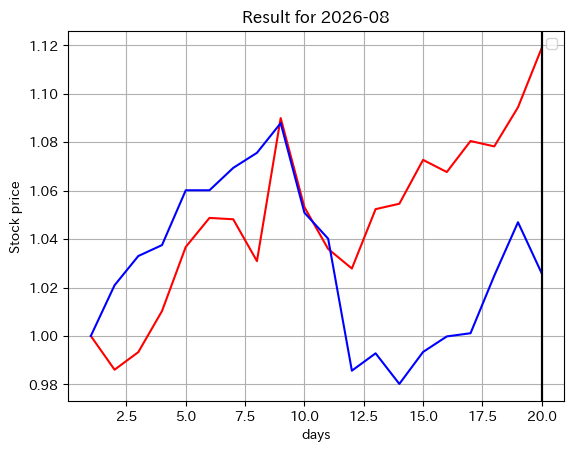

In [ ]:
y0 = 0
win = 0
i=-1
colors = ["red", "blue"]
for index_name in tickers.keys():
    i+= 1
    # データ生成
    y = data[index_name]/data[index_name].iat[0,0]
    if y.iat[len(data[index_name])-1,0] > y0:
        y0 = y.iat[len(data[index_name])-1,0]
        win = i
    x = np.linspace(1, len(y),len(y))

    # プロット作成
    plt.plot(x, y, label="", color=colors[i], linestyle="-")
    plt.title(f"Result for {m}") # タイトル設定
    plt.xlabel("days") # X軸ラベル
    plt.ylabel("Stock price") # Y軸ラベル
    plt.legend() # 凡例表示
    plt.grid(True) # グリッド線表示
    plt.axvline(len(data[index_name]),0,color="black")
if win ==0:
    winner = stock_a_name
else:
    winner = stock_b_name
print(f"Winnner is {winner}")

file_name = f"{m}_res_{winner}.png"
plt.savefig(file_name)
files.download(file_name)
plt.show() # グラフ表示